In [1]:
import imageio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.ndimage as ndi
import numpy as np
import pydicom as dcm
import os
import itertools
import pandas as pd

from module.preprocessing import *

from skimage import exposure, filters, morphology, measure, color, img_as_float

# DICOM

In [14]:
directory = "../dataset/Assigment1/ct-scan/dicom_dir/"

dicom_files = [f for f in os.listdir(directory) if f.endswith('.dcm')]

images = []

for file in dicom_files:
    file_path = os.path.join(directory, file)
    ds = dcm.dcmread(file_path)
    images.append(ds.pixel_array) 

print(f"Loaded {len(images)} images.")


im = images[41]
im.shape

Loaded 100 images.


(512, 512)

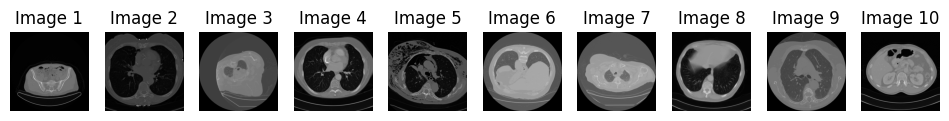

In [3]:
fig, ax = plt.subplots(1, 10, figsize=(12, 6))

# Display only 10 images for visualization
for i in range(10):
    ax[i].imshow(images[i+40], cmap='gray')
    ax[i].set_title(f"Image {i+1}")
    ax[i].axis("off")

plt.show()

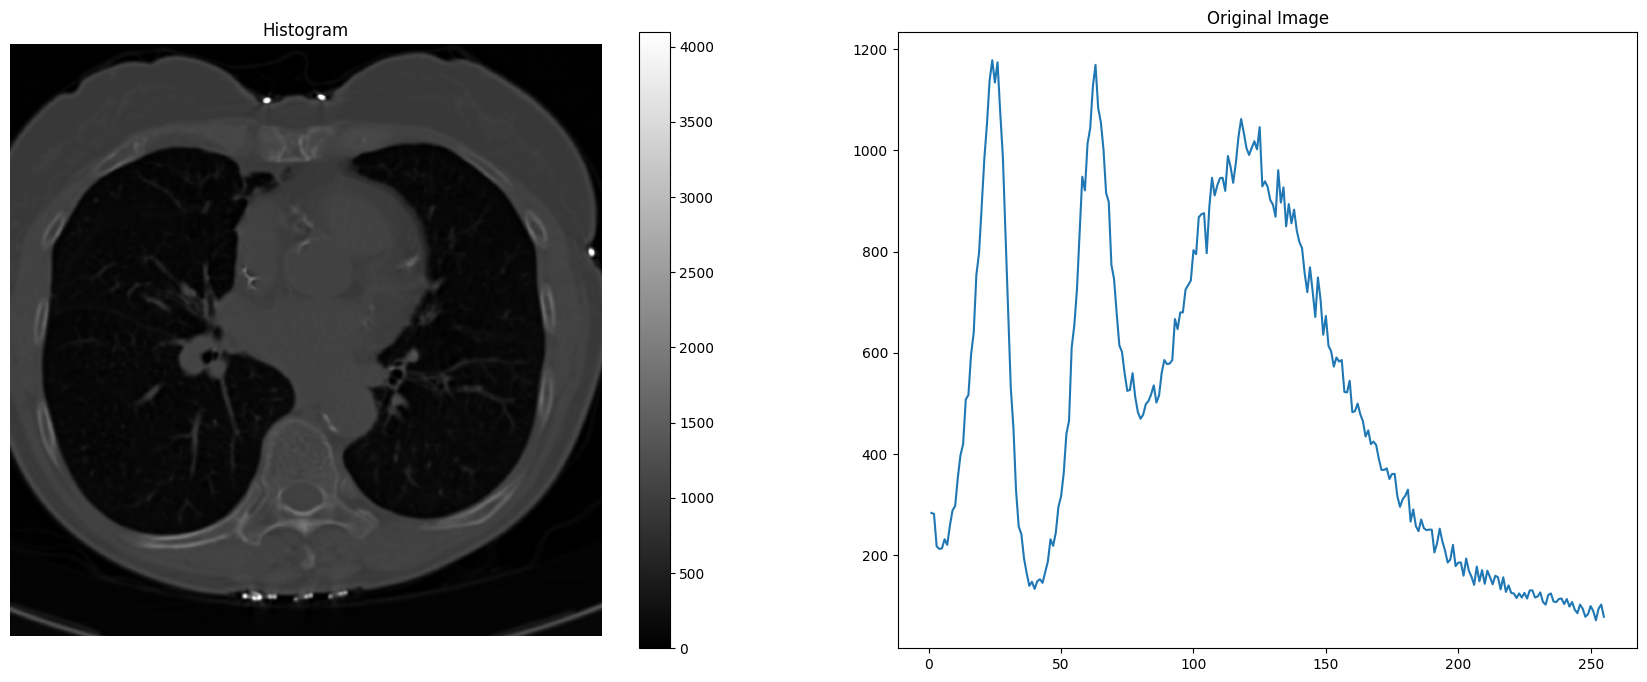

In [4]:
im = images[41] # 4, 17, 18, 25, 30, 34,36, 37, 41, 43 excellent dataset for classic computer vision
hist = ndi.histogram(im, min=0, max=255, bins=256)
x = np.arange(1, len(hist))

fig, ax = plt.subplots(1, 2, figsize=(21, 8))

im_display = ax[0].imshow(im, cmap='gray')
ax[0].set_title('Histogram')
ax[0].axis('off')

ax[1].plot(x, hist[1:])
ax[1].set_title('Original Image')

fig.colorbar(im_display, ax=ax[0])

plt.show()

MSE: 659.0272750854492
1 PSNR: 19.941769718065586
MSE: 4038.042724609375
2 PSNR: 12.069094511726398
MSE: 8561.881065368652
3 PSNR: 8.805111701905561
MSE: 16889.012699127197
5 PSNR: 5.8547609861801595
MSE: 24116.507259368896
7 PSNR: 4.3076595075885775
MSE: 174.4949951171875
3 PSNR: 25.71297385871619
MSE: 1299.3477020263672
5 PSNR: 16.993549781818604
MSE: 3682.879306793213
7 PSNR: 12.468928742292833
MSE: 8336.972206115723
11 PSNR: 8.920720072239039
           Method  Sigma  Median  Clip           MSE       PSNR
5    Median+CLAHE    NaN     3.0   0.1    174.494995  25.712974
0  Gaussian+CLAHE    1.0     NaN   0.1    659.027275  19.941770
6    Median+CLAHE    NaN     5.0   0.1   1299.347702  16.993550
7    Median+CLAHE    NaN     7.0   0.1   3682.879307  12.468929
1  Gaussian+CLAHE    2.0     NaN   0.1   4038.042725  12.069095
8    Median+CLAHE    NaN    11.0   0.1   8336.972206   8.920720
2  Gaussian+CLAHE    3.0     NaN   0.1   8561.881065   8.805112
3  Gaussian+CLAHE    5.0     NaN   0.

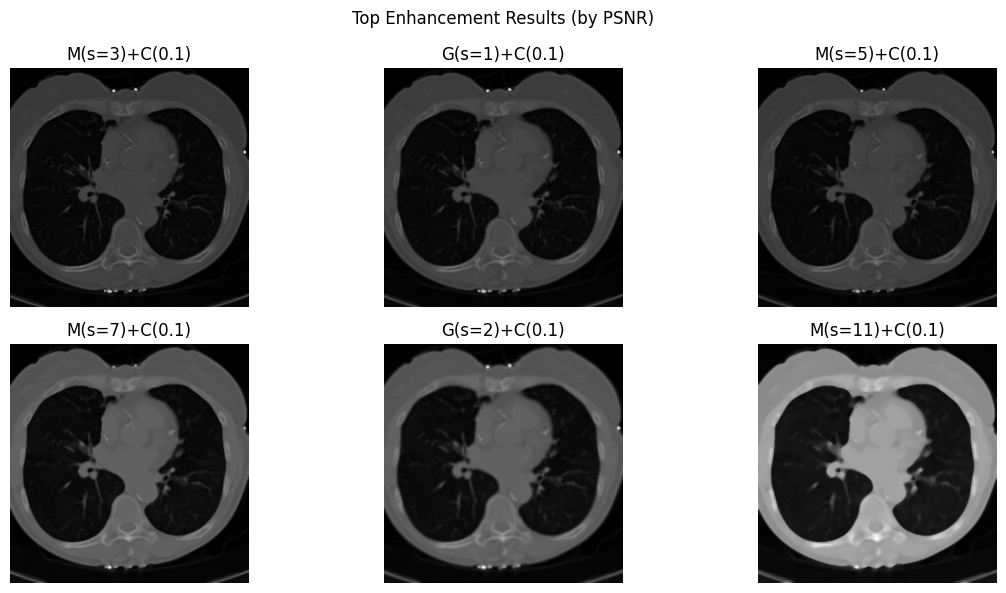

In [5]:
# ---- Parameter Space ----
sigma_values = [1, 2, 3, 5, 7]
median_sizes = [3, 5, 7, 11]
clip_limits = [0.1]

# ---- Storage ----
results = []
records = []

original = im.astype(np.float64)

for sigma, clip in itertools.product(sigma_values, clip_limits):
    filtered = ndi.gaussian_filter(im, sigma=sigma)

    mse = MSE(sigma, original, filtered)
    psnr = PSNR(sigma, original, filtered)

    results.append((f"G(s={sigma})+C({clip})", filtered))
    records.append({
        "Method": "Gaussian+CLAHE",
        "Sigma": sigma,
        "Median": None,
        "Clip": clip,
        "MSE": mse,
        "PSNR": psnr
    })

for size, clip in itertools.product(median_sizes, clip_limits):
    filtered = ndi.median_filter(im, size=size)

    mse = MSE(size, original, filtered)
    psnr = PSNR(size, original, filtered)

    results.append((f"M(s={size})+C({clip})", filtered))
    records.append({
        "Method": "Median+CLAHE",
        "Sigma": None,
        "Median": size,
        "Clip": clip,
        "MSE": mse,
        "PSNR": psnr
    })

df = pd.DataFrame(records)

df_sorted = df.sort_values(by="PSNR", ascending=False)

print(df_sorted.head(10))

top_n = 6
top_indices = df_sorted.head(top_n).index

plt.figure(figsize=(12,6))
for i, idx in enumerate(top_indices):
    name, img = results[idx]
    plt.subplot(2, 3, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(name)
    plt.axis('off')

plt.suptitle("Top Enhancement Results (by PSNR)")
plt.tight_layout()
plt.show()

(-0.5, 511.5, 511.5, -0.5)

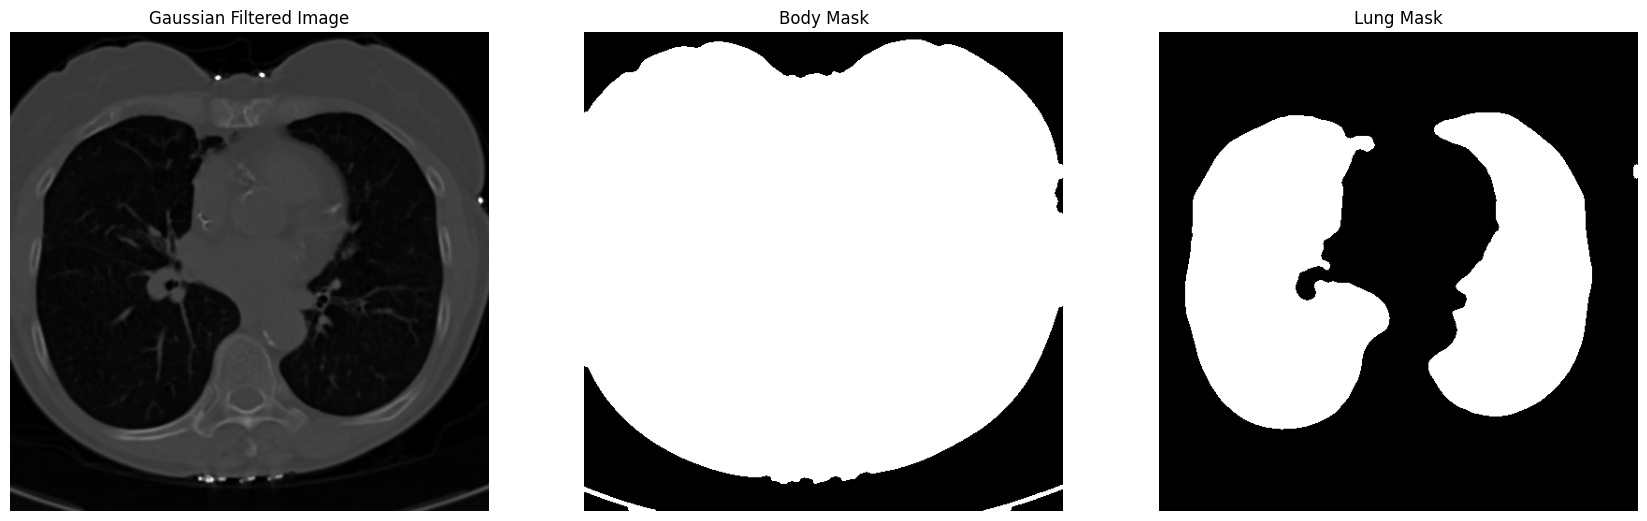

In [6]:
# make body masking
img_filt = ndi.median_filter(im, size=3)

th_body = filters.threshold_otsu(img_filt)
body = img_filt > th_body
body = morphology.binary_closing(body, morphology.disk(5))
body = ndi.binary_fill_holes(body)

# get lungs masking
th_lung = filters.threshold_otsu(img_filt)
lung = (img_filt < th_lung) & body
lung = morphology.binary_closing(lung, morphology.disk(5))
lung = ndi.binary_fill_holes(lung)
lung = morphology.binary_opening(lung, morphology.disk(3))

# plt.imshow(img_filt, cmap='gray')

fig, ax = plt.subplots(1, 3, figsize=(21, 8))
ax[0].imshow(img_filt, cmap='gray')
ax[0].set_title('Gaussian Filtered Image')
ax[0].axis('off')
ax[1].imshow(body, cmap='gray')
ax[1].set_title('Body Mask')
ax[1].axis('off')
ax[2].imshow(lung, cmap='gray')
ax[2].set_title('Lung Mask')
ax[2].axis('off')

In [7]:
lung_mask = lung.copy()

labeled = measure.label(lung)
props = sorted(measure.regionprops(labeled), key=lambda r: r.area, reverse=True)

lung_props = sorted(props[:2], key=lambda r: r.centroid[1])   # sort left→right
L, R = lung_props[0].bbox, lung_props[1].bbox

roi_r0 = max(L[0], R[0])                    # top    of overlap zone
roi_r1 = min(L[2], R[2])                    # bottom of overlap zone
roi_c0 = L[3]                               # right edge of left lung
roi_c1 = R[1]                               # left  edge of right lung

h_pad  = int((roi_c1 - roi_c0)* 0.8)
v_pad  = int((roi_r1 - roi_r0) * 0.01) 
roi_r0 = max(0,          roi_r0 - v_pad) 
roi_r1 = min(im.shape[0], roi_r1 + v_pad) - 100 
roi_c0 = max(0,          roi_c0 - h_pad) - 50
roi_c1 = min(im.shape[1], roi_c1 + h_pad) + 50

roi = im[roi_r0:roi_r1, roi_c0:roi_c1]

th_roi    = filters.threshold_otsu(roi)
heart_bin = roi > th_roi

hl        = measure.label(heart_bin)
hr        = sorted(measure.regionprops(hl), key=lambda r: r.area, reverse=True)
heart_roi = hl == hr[0].label

heart_full = np.zeros(im.shape, dtype=bool)
heart_full[roi_r0:roi_r1, roi_c0:roi_c1] = heart_roi

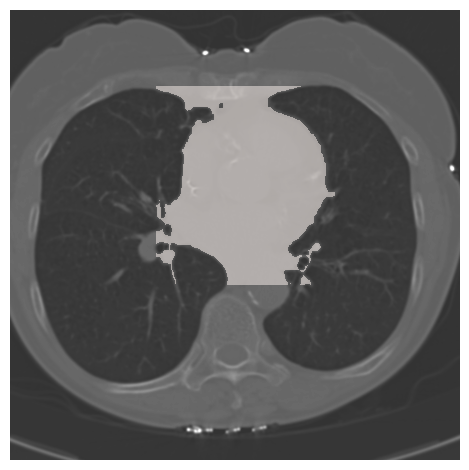

In [8]:
plt.imshow(im, cmap="gray", alpha=0.8)
plt.imshow(np.ma.masked_where(~heart_full, heart_full), cmap='Reds', alpha=0.5)
plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
voxel_size = 1.0  # mm³ CT scan voxel size

heart_props = measure.regionprops(measure.label(heart_full))[0]

heart_volume = np.sum(heart_full) * voxel_size  # mm³
heart_density = np.mean(im[heart_full])  # mean intensity
heart_bbox = heart_props.bbox  # (min_r, min_c, max_r, max_c)
heart_height = heart_bbox[2] - heart_bbox[0]
heart_width = heart_bbox[3] - heart_bbox[1]
heart_size = heart_props.area * voxel_size

labeled_lungs = measure.label(lung_mask)
lung_props = sorted(measure.regionprops(labeled_lungs), key=lambda r: r.centroid[1])

feature_vector = {}

feature_vector['Heart_Volume'] = heart_volume
feature_vector['Heart_Density'] = heart_density
feature_vector['Heart_Height'] = heart_height
feature_vector['Heart_Width'] = heart_width
feature_vector['Heart_AspectRatio'] = heart_height / (heart_width + 1e-6)
feature_vector['Heart_Elongation'] = heart_props.major_axis_length / (heart_props.minor_axis_length + 1e-6)
feature_vector['Heart_Area'] = heart_props.area

for idx, lung_side in enumerate(['Left', 'Right']):
    if idx < len(lung_props):
        lung = lung_props[idx]
        bbox = lung.bbox
        prefix = lung_side + '_Lung_'
        
        feature_vector[prefix + 'Volume'] = lung.area * voxel_size
        feature_vector[prefix + 'Density'] = np.mean(im[labeled_lungs == lung.label])
        feature_vector[prefix + 'Height'] = bbox[2] - bbox[0]
        feature_vector[prefix + 'Width'] = bbox[3] - bbox[1]
        feature_vector[prefix + 'AspectRatio'] = (bbox[2] - bbox[0]) / (bbox[3] - bbox[1] + 1e-6)
        feature_vector[prefix + 'Elongation'] = lung.major_axis_length / (lung.minor_axis_length + 1e-6)
        feature_vector[prefix + 'Area'] = lung.area

feature_df = pd.DataFrame([feature_vector])

feature_df

Feature Vector (Dictionary):
{'Heart_Volume': 31881.0, 'Heart_Density': 1012.9295191493366, 'Heart_Height': 228, 'Heart_Width': 205, 'Heart_AspectRatio': 1.1121951165258774, 'Heart_Elongation': 1.2947120137382289, 'Heart_Area': 31881.0, 'Left_Lung_Volume': 50774.0, 'Left_Lung_Density': 167.31604758340882, 'Left_Lung_Height': 336, 'Left_Lung_Width': 219, 'Left_Lung_AspectRatio': 1.5342465683367736, 'Left_Lung_Elongation': 1.7902234092451406, 'Left_Lung_Area': 50774.0, 'Right_Lung_Volume': 36612.0, 'Right_Lung_Density': 177.1878892166503, 'Right_Lung_Height': 325, 'Right_Lung_Width': 175, 'Right_Lung_AspectRatio': 1.8571428465306123, 'Right_Lung_Elongation': 2.2629454121434276, 'Right_Lung_Area': 36612.0}


,Heart_Volume,Heart_Density,Heart_Height,Heart_Width,Heart_AspectRatio,Heart_Elongation,Heart_Area,Left_Lung_Volume,Left_Lung_Density,Left_Lung_Height,...,Left_Lung_AspectRatio,Left_Lung_Elongation,Left_Lung_Area,Right_Lung_Volume,Right_Lung_Density,Right_Lung_Height,Right_Lung_Width,Right_Lung_AspectRatio,Right_Lung_Elongation,Right_Lung_Area
0,31881.0,1012.929519,228,205,1.112195,1.294712,31881.0,50774.0,167.316048,336,...,1.534247,1.790223,50774.0,36612.0,177.187889,325,175,1.857143,2.262945,36612.0
